In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from datetime import datetime
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

import tensorflow as tf

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-crunch-round-1/sample_submission.csv
/kaggle/input/data-crunch-round-1/train.csv
/kaggle/input/data-crunch-round-1/test.csv


In [50]:
df = pd.read_csv("/kaggle/input/data-crunch-round-1/train.csv")
df['Date'] = df.apply(lambda row: datetime(year=2018+row['Year'], 
                                                     month=row['Month'], 
                                                     day=row['Day']), axis=1)
df['Wind_Direction'] = df['Wind_Direction'].apply(lambda x:(x+45)%360)
df['WindVX'] = df['Wind_Speed'] * np.cos(np.radians(df['Wind_Direction']))
df['WindVY'] = df['Wind_Speed'] * np.sin(np.radians(df['Wind_Direction']))

cdate = ['Year', 'Month', 'Day']
cloc = ['latitude', 'longitude']
ck = ['kingdom']
# ctarget = ['Avg_Temperature', 'Radiation', 'Rain_Amount', 'WindVX', 'WindVY']
cdrop = ['Avg_Feels_Like_Temperature', 'Temperature_Range', 'Feels_Like_Temperature_Range', 'Rain_Duration', 'Evapotranspiration', 'Wind_Speed', 'Wind_Direction']
kingdoms = df["kingdom"].unique().tolist()
K_kingdoms = df[df['Avg_Temperature']>200]["kingdom"].unique().tolist()

c_target = ['Avg_Temperature', 'Radiation', 'Rain_Amount', 'WindVX', 'WindVY']



c_feature = ['Avg_Temperature', 'Radiation', 'Rain_Amount', 'WindVX', 'WindVY',
       'sin_day_of_354', 'cos_day_of_354', 'sin_day_of_188', 'cos_day_of_188',
       'sin_day_of_177', 'cos_day_of_177','sin_day_of_404', 'cos_day_of_404']

periods = [354, 188, 177, 404]

df['Avg_Temperature'] = df['Avg_Temperature'].apply(lambda x: x - 273.15 if x > 200 else x)

df.drop(columns=cdrop+cdate+cloc, inplace=True)

df = df[c_target+['kingdom', 'Date', 'ID']]

kingdom_groups = {kingdom: {'df': data} for kingdom, data in df.groupby('kingdom')}



def smape(y_true, y_pred):
    epsilon = tf.keras.backend.epsilon()  # Small value to avoid division by zero
    numerator = tf.abs(y_true - y_pred)
    denominator = (tf.abs(y_true) + tf.abs(y_pred) + epsilon) / 2
    return tf.reduce_mean(numerator / denominator) * 100  # Convert to percentage

def create_lagged_features(df, lag=3):
    df_lagged = df.copy()

    for i in range(1, lag + 1):
        df_lagged[[f"{col}_lag{i}" for col in df.columns]] = df.shift(i)
    df_lagged = df_lagged[lag+1:]

    dates = df_lagged.index.to_numpy().reshape(len(df_lagged), 1)
    X = df_lagged.drop(columns=c_feature).to_numpy().reshape(len(df_lagged), lag, len(c_feature))
    Y = df_lagged[c_target].to_numpy()

    return dates, X, Y
    
    

def add_lag(df):
    lag_n = 3
    for feature in ctarget:
        for lag in range(1, lag_n):
            df[f'{feature}_lag_{lag}'] = df[feature].shift(lag)
    return df[lag_n-1:]

def add_period(df):
    
    # df['year'] = df['Date'].dt.year
    # df['month'] = df['Date'].dt.month
    # df['day'] = df['Date'].dt.day
    
    for p in periods:
        day_of_p = ((df['Date'] - df['Date'].min()).dt.days % p) + 1
        df[f'sin_day_of_{p}'] = np.sin(2 * np.pi * day_of_p / p)
        df[f'cos_day_of_{p}'] = np.cos(2 * np.pi * day_of_p / p)
    df.set_index('Date', inplace=True)
    return df
    
def make_and_split(df):
    dates, X, Y = create_lagged_features(df)
    train_ix = int(len(dates) * 0.8)
    val_ix = int(len(dates) * 0.9)
    
    train_dates, train_X, train_Y = dates[:train_ix], X[:train_ix], Y[:train_ix]
    val_dates, val_X, val_Y = dates[train_ix:val_ix], X[train_ix:val_ix], Y[train_ix:val_ix]
    test_dates, test_X, test_Y = dates[val_ix:], X[val_ix:], Y[val_ix:]

    return {
        'train': {
            'dates': train_dates,
            'X': train_X,
            'Y': train_Y
        }, 
        'val': {
            'dates': val_dates,
            'X': val_X,
            'Y': val_Y
        },
        'test': {
            'dates': test_dates,
            'X': test_X,
            'Y': test_Y
        }
    }

def new_model():
    model = Sequential([
        layers.LSTM(128),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(len(c_target))
    ])
    model.compile(loss='mse', optimizer=Adam(), metrics=[smape])
    return model

for k in kingdom_groups:
    # kingdom_groups[k]['df'] = add_lag(kingdom_groups[k]['df'])
    kingdom_groups[k]['df'] = add_period(kingdom_groups[k]['df'])
    kingdom_groups[k]['df'].drop(columns=['ID', 'kingdom'], inplace=True)
    kingdom_groups[k]['split'] = make_and_split(kingdom_groups[k]['df'])
    kingdom_groups[k]['model'] = new_model()
    kingdom_groups[k]['buffer'] = list(kingdom_groups[k]['df'].iloc[-3:].to_numpy())


def fit_model(kingdom, epochs=10):
    train_X = kingdom['split']['train']['X']
    train_Y = kingdom['split']['train']['Y']
    val_X = kingdom['split']['val']['X']
    val_Y = kingdom['split']['val']['Y']
    kingdom['model'].fit(train_X, train_Y, validation_data=(val_X, val_Y), epochs=epochs)

def draw_comp(preds, act, dates, i):
    feature_preds = preds[:, i:i+1].flatten()
    feature_act = act[:, i:i+1].flatten()
    
    plt.plot(dates, feature_preds, ".", markersize="2")
    plt.plot(dates, feature_act, ".", markersize="2")
    plt.title(c_target[i])
    plt.legend(['Prediction', 'Actual'])
    
    smape_value = smape(
        tf.convert_to_tensor(feature_act, dtype=tf.float32), 
        tf.convert_to_tensor(feature_preds, dtype=tf.float32)
    )
    smape_value_while = smape(
        tf.convert_to_tensor(act, dtype=tf.float32), 
        tf.convert_to_tensor(preds, dtype=tf.float32)
    )
    
    print(smape_value.numpy(), smape_value_while.numpy())


k_itr = iter(kingdom_groups.items())

kingdoms = kingdom_groups

In [ ]:
input_layer = Input(shape=(X_train.shape[1], 1))

x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(pool_size=2)(x)
x = LSTM(32, return_sequences=False)(x)

x = Dense(16, activation='relu')(x)
output = Dense(1, activation='linear')(x)

model = Sequential([
    Input(shape=(len(features),)),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    LSTM(32, return_sequences=False),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

In [ ]:


input_layer = Input(shape=(len(time_features) + len(location_features),))

x = Dense(64, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)

model = Sequential([
    Input(shape=(len(features),)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

In [65]:
for i, k in enumerate(kingdoms):
    print(f"{i}/{len(kingdoms)} {k}")
    fit_model(kingdoms[k], 5)

0/30 Arcadia
Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 235.8138 - smape: 138.7873 - val_loss: 39.8503 - val_smape: 42.4364
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 58.4497 - smape: 44.2298 - val_loss: 32.6784 - val_smape: 41.0551
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 62.5097 - smape: 42.8284 - val_loss: 29.4461 - val_smape: 40.2548
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 43.7797 - smape: 41.2958 - val_loss: 27.9375 - val_smape: 41.1705
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38.9242 - smape: 40.9557 - val_loss: 27.4701 - val_smape: 39.4644
1/30 Atlantis
Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.0829 - smape: 40.4011 - val_loss: 34.6107 - val_smape: 58.4495
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.4216 - smape: 40.7087 - val_loss: 34.0183 - val_smape: 58.0758
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.8505 - smape: 39.4911 - val_loss: 34.8565 - val_sma

In [128]:
date_buffer = list(kingdoms['Arcadia']['df'].iloc[-3:].index)

def extend_date_buffer(n_days):
    for i in range(n_days):
        date_buffer.append(date_buffer[-1]+pd.Timedelta(days=1))

def next_date(buffer):
    return date_buffer[len(buffer)]

def generate_record(date, data):
    date_arr = []
    for p in periods:
        day_of_p = ((date - df['Date'].min()).days % p) + 1
        date_arr.append(np.sin(2 * np.pi * day_of_p / p))
        date_arr.append(np.cos(2 * np.pi * day_of_p / p))
    date_arr = np.array(date_arr)
    return np.concatenate((data, date_arr))
    
def getwindow(buffer):
    return np.array(buffer[-3:][::-1]).reshape(1, 3, 13)

def fill_buffer(buffer, model):
    n_remaining = len(date_buffer) - len(buffer)
    for i in range(n_remaining):
        window = getwindow(buffer)
        pred = model.predict(window)
        data = generate_record(next_date(buffer), pred[0])
        buffer.append(data)

extend_date_buffer(300)

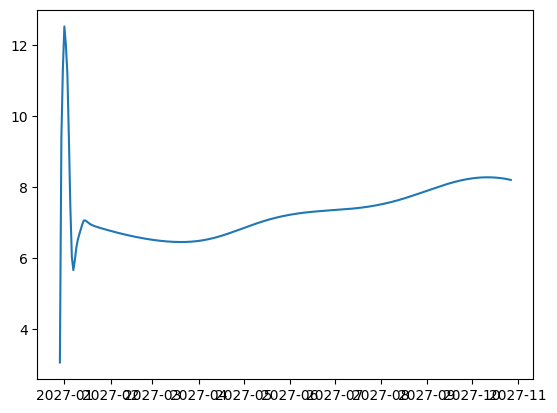

In [136]:
plt.plot(date_buffer, list(map(lambda r:r[4], buffer)))

In [129]:
len(date_buffer)

303

In [130]:
k = kingdoms['Utopia']
buffer = k['buffer']
model = k['model']
fill_buffer(buffer, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

In [102]:
next_date(buffer)

Timestamp('2027-01-02 00:00:00')

In [101]:
buffer.append(generate_redord(datetime.now(), pred[0]))

In [72]:
pred

array([[26.915733 , 21.533047 ,  4.6415167, -5.719777 , 12.516356 ]],
      dtype=float32)

In [62]:
k = kingdoms['Atlantis']

model = k['model']


train_X = k['split']['train']['X']
test_Y = k['split']['train']['Y']
test_dates = k['split']['train']['dates']

test_preds = model.predict(train_X)


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [61]:
test_preds = model.predict(test_X)

NameError: name 'test_X' is not defined

In [54]:

i=3
Avg_Temperature_preds = train_preds[:, i:i+1].flatten()
Avg_Temperature_act = train_Y[:, i:i+1].flatten()

plt.plot(train_dates, Avg_Temperature_preds, ".", markersize="2")
plt.plot(train_dates, Avg_Temperature_act, ".", markersize="2")
plt.title(c_target[i])
plt.legend(['Prediction', 'Actual'])

smape_value = smape(
    tf.convert_to_tensor(Avg_Temperature_act, dtype=tf.float32), 
    tf.convert_to_tensor(Avg_Temperature_preds, dtype=tf.float32)
)
smape_value_while = smape(
    tf.convert_to_tensor(train_Y, dtype=tf.float32), 
    tf.convert_to_tensor(train_preds, dtype=tf.float32)
)

print(smape_value.numpy(), smape_value_while.numpy())

NameError: name 'train_Y' is not defined

87.51735 40.011135


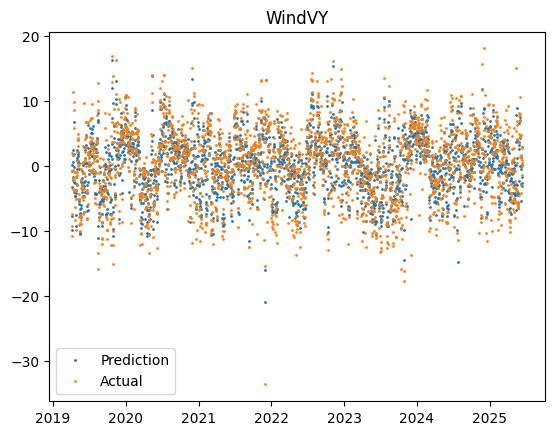

In [63]:
draw_comp(test_preds, test_Y, test_dates, 4)

In [ ]:
def generate_redord(date, data):
    date_arr = []
    for p in periods:
        day_of_p = ((date - df['Date'].min()).days % p) + 1
        date_arr.append(np.sin(2 * np.pi * day_of_p / p))
        date_arr.append(np.cos(2 * np.pi * day_of_p / p))
    date_arr = np.array(date_arr)
    return np.concatenate((data, date_arr))
    
def getwindow(buffer):
    return np.array(buffer[-3:][::-1]).reshape(1, 3, 13)
    

In [ ]:
buffer = list(k1['df'].iloc[-3:].to_numpy())

In [ ]:
np.concatenate((buffer[-3:][::-1]),axis=1)

In [ ]:
np.array(buffer[-3:][::-1]).reshape(1, 3, 13).shape

In [ ]:
k1['df'][c_target].iloc[0].to_numpy()

In [ ]:
add_date_info(datetime(year=2019, month=4, day=1), k1['df'][c_target].iloc[0].to_numpy())

In [ ]:
k1['df'][c_target].iloc[0].to_numpy()